# Bearing Off
### Teaching a Neural Network to Play Backgammon with Temporal Difference Learning 
##### By Wills Erda, Camiel Schroeder, and Shingo Kodama
##### GitHub: https://github.com/GillsSpace/Final_Project/tree/main


In [20]:
import os
import sys
import time
import torch
import torchinfo
import numpy as np
import pandas as pd

import scr.Logic as Logic
import scr.Models as Models
import scripts.Validation as Validation

In [ ]:
MODEL_NAME = 'GnubgSupervised_final'
MODEL = f'{MODEL_NAME}.pickle'
MODEL_TYPE = Models.Model_GnubgSupervised
INPUT_SIZE = (1,198)
sys.modules['Models'] = Models

model = Models.Model_Loader.load_model(MODEL)

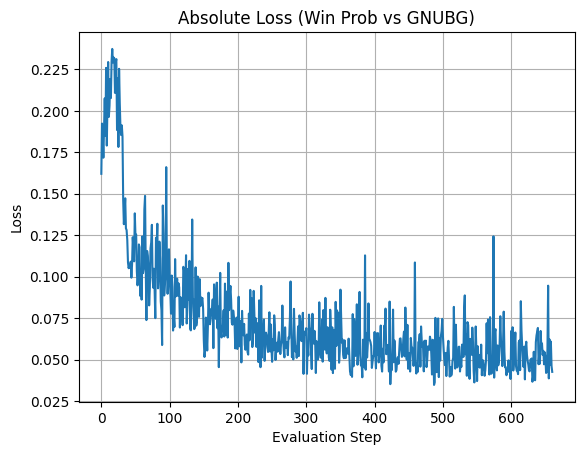

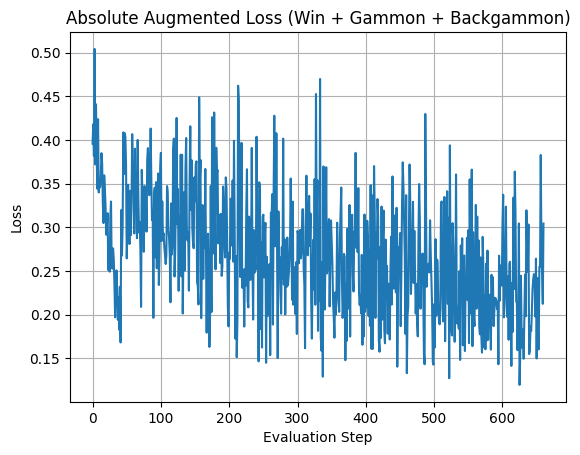

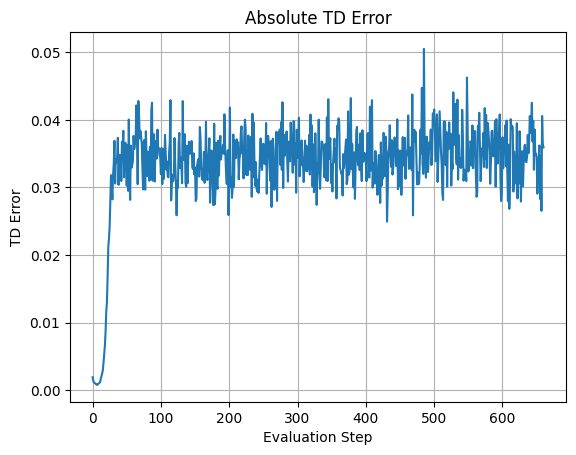

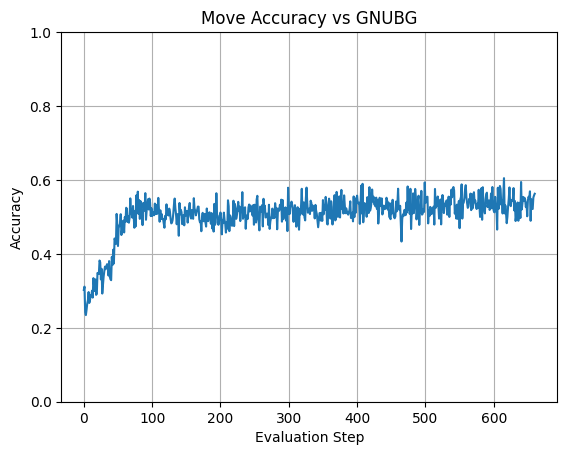

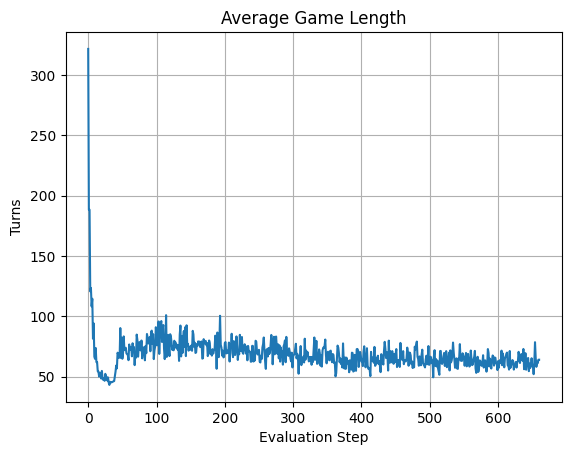

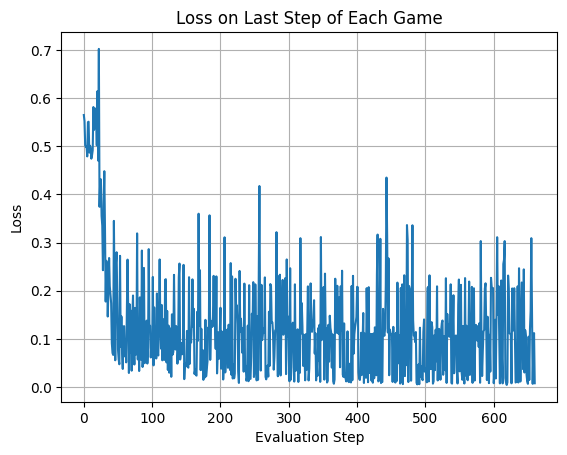

In [26]:
Logic.plot_training_history(model, MODEL_NAME)

## Abstract

Backgammon poses a fascinating challenge for reinforcement learning, as meaningful feedback is spare throughout the game, and is convoluted by the inherent randomness of 21 distinct dice outcomes for every position. To tackle this stochasticity, we have built three different neural network agents trained with different learning signals to investigate how supervision source and feature representation affect move quality. Our baseline followed the industry standard Tesauro's TD-Gammon architecture, using temporal difference learning with eligibility traces and raw board encoding. A second model replaced self-play with direct supervision from GNU Backgammon via Adam and MSE loss, replacing an internal bootstrap target with a more stable external one. A third replaced raw board features with 19 hand-crafted positional features encoding blot exposure, prime formation, and bearing-off readiness. 

## Introduction

Humans have been playing backgammon for roughly 5000 years. Accumulated intuition and strategy awareness has allowed the world's expert players to greatly expand the skill differential. Teaching a machine is an entirely different learning curve, one which sits at the intersection of game theory, reinforcement- and representation learning. We therefore believe backgammon, which benefits from a large body of pre-existing academic work,  is an informative proxy and learning tool for a larger category of problems that cannot be solved by stock implementations of the algorithms learned in this class: problems with no pre-existing data on the correct targets, as the source of truth is very expensive to get at every step. Furthermore, the training data is generated by the agent playing, meaning the distribution of states available to our model is dependent on how good the model’s current policy is. An agent that handles randomness, sparse rewards, and long-horizon dependencies would have transferable applications in other stochastic, information dense fields, such as algorithmic trading or robotic manipulation.

One of the landmark results in this space is Tesauro's TD-Gammon.[^1] TD-Gammon was constructed in such a fashion to leverage the capabilities of multilayer neural networks, trained by TD(λ), to learn complex nonlinear functions. Notably, the input representation only encoded the raw state of the board. Any strategic features or complex interdependencies that a human player might utilize, the model would have to learn by itself. This choice Tesauro describes as a practical starting point, but by no means optimal.  In their textbook on reinforcement learning Barto and Sutton go on to describe the exact feature set Tesauro used and note, "basically, Tesauro tried to represent the position in a straightforward way, while keeping the number of units relatively small. He provided one unit for each conceptually distinct possibility that seemed likely to be relevant, and he scaled them to roughly the same range, in this case between 0 and 1."[^2] However they offer not justification as to why these choices are optimal. 

Self-play and reinforcement learning becomes especially interesting in contrast to alternatives. BKG, a model developed by Hans Berliner at Carnegie Mellon University in the late 1970s utilized zero machine learning.[^3] Instead, Berliner hand-coded met with top human players over several years and encoded their expertise directly into roughly 30 hand-crafted microstrategies  (In 1979, BKG beat the newly crowned world champion, aided by a few lucky dice rolls). Tesauro believed the benefit of such features depended on network capacity: smaller networks would gain significant improvement from engineered features, less so for larger networks; sufficient model capacity can compensate for a weaker representation.[^4] This tradeoff was of great interest to us: we have limited compute, and so set out to test whether better representation can allow our models to converge faster, and to see whether simulation-based learning is practical at all outside institutional computing power. 

[^1]: Tesauro, G. (1995). Temporal difference learning and TD-Gammon. Communications of the ACM, 38(3), 58–68. https://dl.acm.org/doi/10.1145/203330.203343 
[^2]: Sutton, Richard S., and Andrew G. Barto. Reinforcement Learning: An Introduction. 2nd ed., MIT Press, 2018, www.andrew.cmu.edu/course/10-703/textbook/BartoSutton.pdf. 
[^3]: Berliner, Hans J. "BKG: A Program That Plays Backgammon." Artificial Intelligence, vol. 14, no. 1–2, 1980, pp. 205–220. 
[^4]: Tesauro, Gerald. "Programming Backgammon Using Self-Teaching Neural Nets." Artificial Intelligence, vol. 134, no. 1–2, 2002, pp. 181–199. doi:10.1016/S0004-3702(01)00110-2. 

## Values Statement

Reinforcement learning agents in the world of board games are generally low-stakes in comparison to its siblings in technological fields. Hopefully, nobody is denied a loan or misdiagnosed because our backgammon bot chooses the wrong game strategy. Direct beneficiaries are therefore individuals curious about how self-play RL actually works. Students such as ourselves, but hobbyists and researchers too who want a well-understood domain to experiment in. Beyond that, there are benefits to those who seek to improve on RL methodologies. Improvements in RL could transfer to drug discovery pipelines, robotic control systems, or stock pickers, where the stakes (and the potential consequences) are considerably higher.

Exclusion will happen primarily based on interest rather than access. This project, much like the expert models today, are open-source and can be run on most devices (albeit slow). The more genuine ethical concern that is ever prevalent today is potential misuse through online cheating. Backgammon is known for its betting scene, and a strong automated agent could in principle be used to defraud opponents. That being said, we believe this risk to be manageable for two reasons. Our agent will almost certainly not reach a level that can reliably defeat experienced players, compute constraints alone make that unlikely. More importantly, GNU Backgammon plays at a level far beyond what we will achieve, and is also free and open-source. Bad actors simply have better tools available to them. 

Our personal motivations are straightforward. Camiel wanted hands-on experience with temporal difference learning specifically, as he seeks to go beyond the supervised methods to explore alternative approaches such as RL. Wills was drawn mostly to the engineering problem of building a self-play training loop from scratch. He is fascinated by the methods possible to handle legal move generation and environment logic in PyTorch, and welcomes the experience of working in a collaborative Git codebase. Shingo wanted to learn how to design experiments around a learning agent; to understand how to derive meaningful baselines to contrast against, and how to measure progress in absence of a fixed test set. Collectively, backgammon gave all three of us a new dimension to apply our course learnings in, one where the evaluation and the learning signal are not nearly so straightforward.

## Data

Our task does not include a traditional data set, and instead involves the use of an environment on which an agent learns. The species of how this agent learns and how this relates to traditional supervised methods learned in this class is described below. Here, however, is an explanation of how the environment is constructed and our use of the GNUBG engine. 

Our project uses a custom board class that represents a current position in backgammon. This, along with a variable to keep track of whose turn it is and a simple function to generate a random dice roll is all that is needed to play a game of backgammon. The class includes a variety of methods from helper functions such as `is_game_over` to `return_legal_moves` and `execute_move` that allow our agents to consider and then play moves turn after turn until the end of a game is reached. In the reinforcement learning spaces a single complete game is often considered an "episode" and can be thought of in a similar way to epochs. These terms are used interchangeably in this report. While a custom class, `Board` does use a third party library to generate the possible legal moves. This is done both for simplicity and to prevent unnecessary training bottlenecks. More details on this library can be found in the project readme. 

The board also has several methods that allow for the reference of the GNUBG engine. This engine is supported via another python library and is used both as our main method for evaluating the models and also for an experimental model in which we use GNUBG evaluations as the target prediction values at each training step. `return_gnubg_win_probs` will return the engine evaluation for each board state and is used throughout the project. We also use a GNUBG function to return the best move which is used to test the model accuracy by checking against the final board state generated by the move (as is backgammon multiple moves and lead to the same outcome). 

Unfortunately, our board class, GNUBG, and gym Backgammon all use different positional encodings. This is mainly solved by a variety of helper functions found in the board class that serve to convert or translate between the different encodings. Additionally, as part of our experiment was to use a variety of feature representations there are additional conversion functions to the Tesauro encoding and a custom encoding that we developed. As an example of this, the encoding method used by our class and gym Backgammon is shown below.

Finally, for one of our experimental models we decided to try to use a more traditional supervised learning approach to train a model. This involved having GNUBG play 10,000 games against itself and at each move record the position and its evaluation. This generated a csv file with over 600,000 observations. This positional encodings for this use the tesauro method. 

![Position Encodings](BG_Board_Positions.png)

Below you will find a data frame of the training data file used for our traditional supervised learning model. Additionally, we print a a backgammon board in it's starting configuration and list the possible legal moves for the first player rolling a 2,3. Moves are represented as a list of tuples where the first element is the starting position and the second element is the ending position. A move with multiple tuples represents a move with multiple pieces.

In [ ]:
# Data - 1

data = pd.read_csv('data/training_data.csv')
data

,state,win_prob
0,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.533846
1,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",0.495789
2,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.534481
3,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.526004
4,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.596460
...,...,...
626661,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.000000
626662,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.000000
626663,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.000000
626664,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",1.000000


In [ ]:
# Data - 2

board = Logic.Board()
board.render_terminal()
moves = board.return_legal_moves(player=1, dice=(2,3))
print(*moves, sep='\n')

|    | 00   01   02   03   04   05 |    | 06   07   08   09   10   11 |    |
|----|----+----+----+----+----+----|----|----+----+----+----+----+----|----|
| 00 |  X                        O |    |       O                   X |    |
|    |  X                        O | P2 |       O                   X |    |
|    |                           O |    |       O                   X |    |
|    |                           O | O  |                           X |    |
|    |                           O | 00 |                           X |    |
|    |                             |    |                             |    |
|----|                             |    |                             |----|
|    |                             |    |                             |    |
|    |                           X | 00 |                           O |    |
|    |                           X | X  |                           O |    |
|    |                           X |    |       X                   O |    |